In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper


In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)


In [3]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)


In [10]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ['LANGCHAIN_API_KEY']=os.getenv('LANGCHAIN_API_KEY')
os.environ['LANGCHAIN_TRACING_V2']="true"
os.environ['LANGCHAIN_PROJECT']="React-Agent"


In [11]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

Tavily search Tool

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_search=TavilySearchResults()


C:\Users\ArnavBhatia\AppData\Local\Temp\ipykernel_63720\3700627128.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search=TavilySearchResults()


In [12]:
tools.append(tavily_search)
tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\ArnavBhatia\\anaconda3\\envs\\llms\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=500)),
 <function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>,
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]

In [13]:
from langchain_ollama import ChatOllama
ollama=ChatOllama(model="llama3.2:latest")
llm_with_tools=ollama.bind_tools(tools)

In [14]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

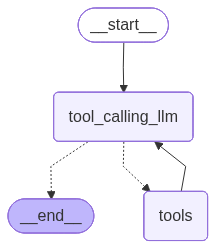

In [ ]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
# ! CHANGE HERE THERE IS REDICECTION HAPPENING BACK TO THE LLM NODE, THIS IS BECAUSE AFTER THE TOOL EXECUTION, WE WANT TO ROUTE BACK TO THE LLM TO GET THE NEXT MESSAGE FROM THE ASSISTANT -> rEACT AGENT BEHAVIORmessages=graph.invoke({"messages":HumanMessage(content="Provide me 10 top AI News, add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print() 
# If it's a tool call, we want to route to the tools node, which will execute the tool and then route back to the LLM node to get the next message from the assistant
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
messages=graph.invoke({"messages":HumanMessage(content="Provide me 10 top AI News, add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me 10 top AI News, add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (28892e1a-6b60-4ca3-a2fe-86abd2984c9f)
 Call ID: 28892e1a-6b60-4ca3-a2fe-86abd2984c9f
  Args:
    query: top AI news
  add (2a9e76af-804c-4219-b225-f047619f809c)
 Call ID: 2a9e76af-804c-4219-b225-f047619f809c
  Args:
    a: 5
    b: 5
  multiply (1a488832-74a1-4aa9-9199-583a9276bbb4)
 Call ID: 1a488832-74a1-4aa9-9199-583a9276bbb4
  Args:
    a: 10
    b: result of add
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "Entertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered

### Agent Memory
#### Aim
Lets introduce Agent With Memory

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (ee31cad2-557a-4396-b01f-9d64b13c367f)
 Call ID: ee31cad2-557a-4396-b01f-9d64b13c367f
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The answer to the original user question, "What is 5 plus 8?", is 13.


In [19]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (87cca417-4a6b-4b06-b2eb-8f97889cb83e)
 Call ID: 87cca417-4a6b-4b06-b2eb-8f97889cb83e
  Args:
    a: 5
    b: 1
================================= Tool Message =================================
Name: divide

5.0
================================== Ai Message ==================================

The result of dividing 5 by 5 is 1.


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

![image.png](attachment:image.png)

In [20]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")




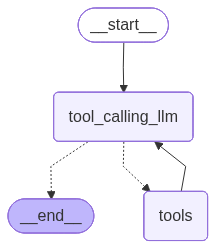

In [21]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
# !  memory saver to save the memory of previous tasks
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [22]:
## Specify the thread

config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (e7cd6a0b-fba7-40c0-8d1e-486ea48aa63b)
 Call ID: e7cd6a0b-fba7-40c0-8d1e-486ea48aa63b
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The answer to the original user question is: 25


In [23]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (e7cd6a0b-fba7-40c0-8d1e-486ea48aa63b)
 Call ID: e7cd6a0b-fba7-40c0-8d1e-486ea48aa63b
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The answer to the original user question is: 25
================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (6a013550-0207-46e2-bf05-7175f447328c)
 Call ID: 6a013550-0207-46e2-bf05-7175f447328c
  Args:
    a: 25
    b: 5
================================= Tool Message =================================
Name: divide

5.0
================================== Ai Message ======